# **Tugas 01 Data Analytics**

Aliya Harta Ary Utama - 18223081

## Data Profiling

In [ ]:
# Import Database
import pandas as pd
df = pd.read_csv("weather_station_data.csv")


df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        50 non-null     object 
 1   temperature_C    48 non-null     float64
 2   humidity_pct     49 non-null     float64
 3   pressure_hPa     48 non-null     float64
 4   wind_speed_ms    49 non-null     float64
 5   light_level_lux  50 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.5+ KB


(50, 6)

In [ ]:
# Missing Value
df.isnull().sum()

timestamp          0
temperature_C      2
humidity_pct       1
pressure_hPa       2
wind_speed_ms      1
light_level_lux    0
dtype: int64

In [ ]:
df.describe()

,temperature_C,humidity_pct,pressure_hPa,wind_speed_ms,light_level_lux
count,48.000000,49.000000,48.000000,49.000000,50.0
mean,27.033542,61.825918,19820.113125,3.034694,450.0
std,2.628890,19.246522,39564.000299,1.142290,0.0
min,22.730000,-15.000000,1012.290000,1.000000,450.0
25%,25.130000,57.430000,1012.995000,2.000000,450.0
50%,26.750000,60.360000,1013.350000,3.090000,450.0
75%,28.695000,64.150000,1013.930000,4.130000,450.0
max,32.490000,150.000000,101395.140000,4.800000,450.0


In [ ]:
df.std(numeric_only=True)

temperature_C          2.628890
humidity_pct          19.246522
pressure_hPa       39564.000299
wind_speed_ms          1.142290
light_level_lux        0.000000
dtype: float64

In [ ]:
# Hitung jumlah nilai yang > 2000
(df['pressure_hPa'] > 2000).sum()

np.int64(9)

In [ ]:
df['pressure_scaled'] = df['pressure_hPa'] / 100

df.loc[df['pressure_hPa'] > 2000, ['pressure_hPa', 'pressure_scaled']]

,pressure_hPa,pressure_scaled
20,101364.55,1013.6455
21,101279.53,1012.7953
22,101395.14,1013.9514
23,101254.91,1012.5491
24,101354.34,1013.5434
26,101275.47,1012.7547
27,101296.69,1012.9669
28,101329.98,1013.2998
29,101299.83,1012.9983


## Identify Error Types

Kita akan mengeksekusi tiap variabel dengan menggunakan statistik, plot untuk menemukan :
a. Stochastic error (random noise / random missing)
b. Deterministic error (systematic offset, wrong unit, wrong formula)
c. Outlier (value far outside valid range)
d. Inlier (value inside global range but locally inconsistent in time)
e. Constant feature (no information)

### Stochastic Error

In [ ]:
print("STOCHASTIC ERROR (Random Missing Values)")
missing = df.isnull().sum()

for col in df.columns:
    if missing[col] > 0:
        print(f"{col} memiliki {missing[col]} missing value [Stochastic Error]")

STOCHASTIC ERROR (Random Missing Values)
temperature_C memiliki 2 missing value [Stochastic Error]
humidity_pct memiliki 1 missing value [Stochastic Error]
pressure_hPa memiliki 2 missing value [Stochastic Error]
wind_speed_ms memiliki 1 missing value [Stochastic Error]


### Deterministic Error

In [ ]:
import numpy as np
df["timestamp"] = pd.to_datetime(df["timestamp"])

numeric_cols = df.select_dtypes(include=np.number).columns

stats = df[numeric_cols].agg(['min','max','mean','std']).T
stats

,min,max,mean,std
temperature_C,22.73,32.49,27.033542,2.628890
humidity_pct,-15.00,150.00,61.825918,19.246522
pressure_hPa,1012.29,101395.14,19820.113125,39564.000299
wind_speed_ms,1.00,4.80,3.034694,1.142290
light_level_lux,450.00,450.00,450.000000,0.000000


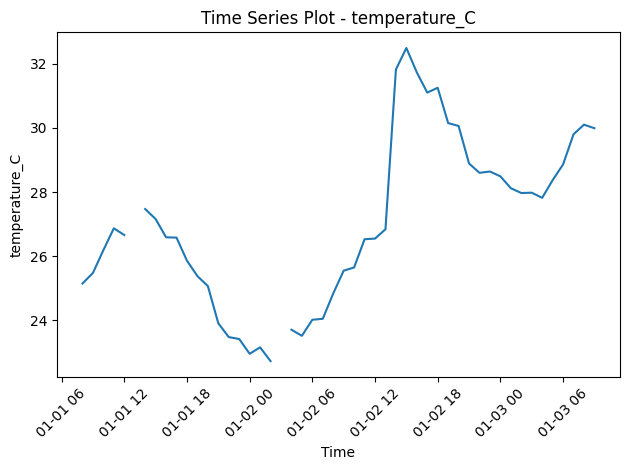

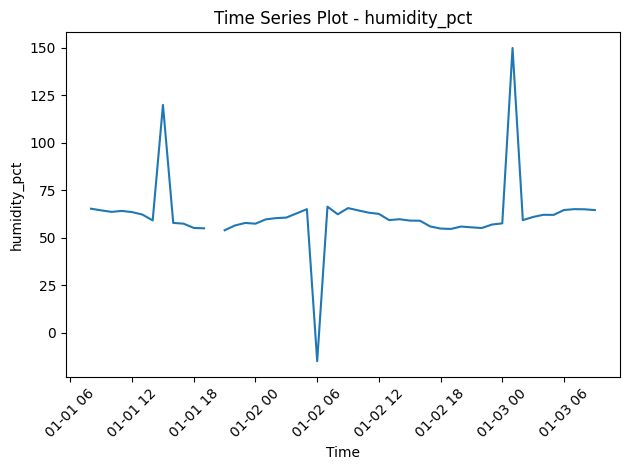

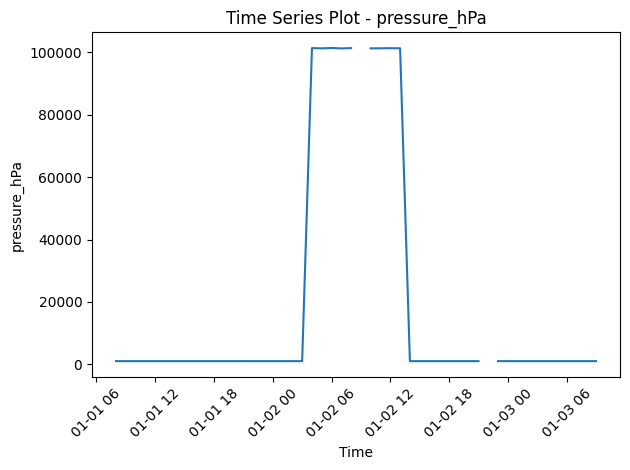

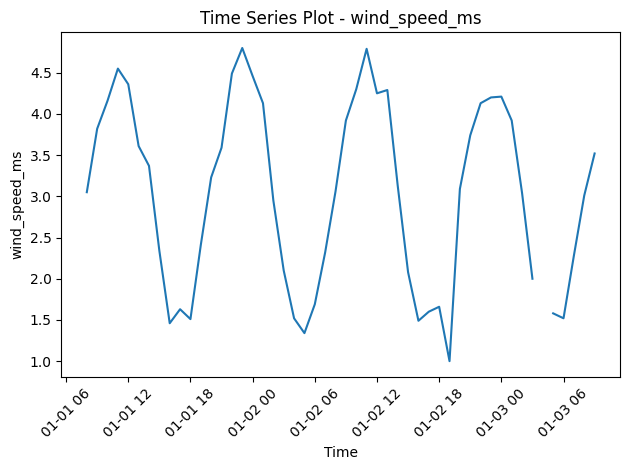

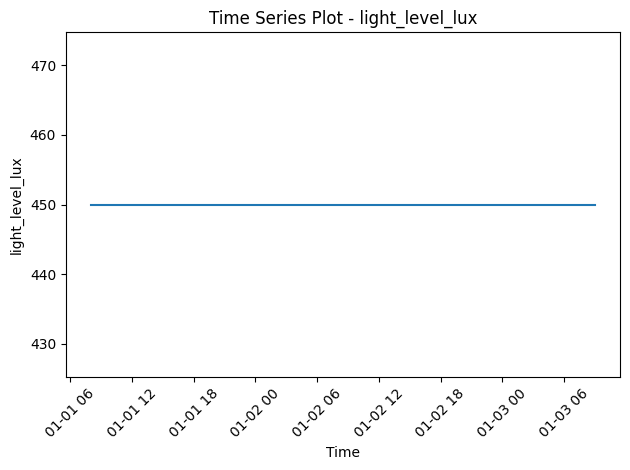

In [ ]:
import matplotlib.pyplot as plt
for col in numeric_cols:
    plt.figure()
    plt.plot(df["timestamp"], df[col])
    plt.title(f"Time Series Plot - {col}")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

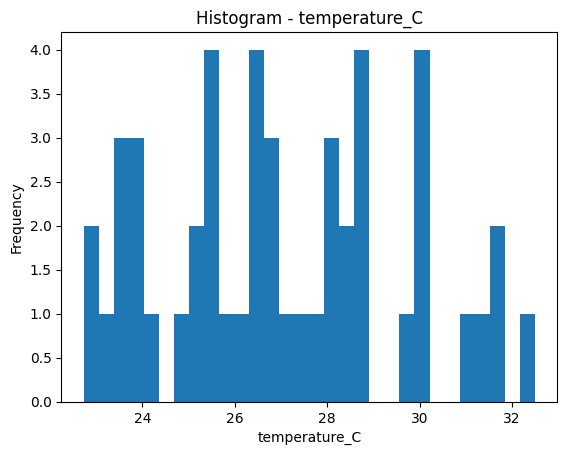

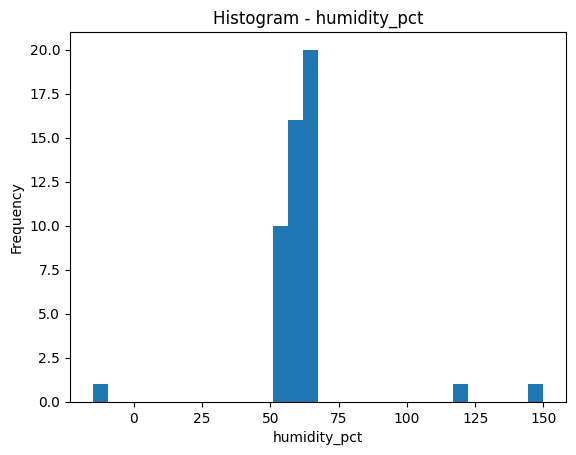

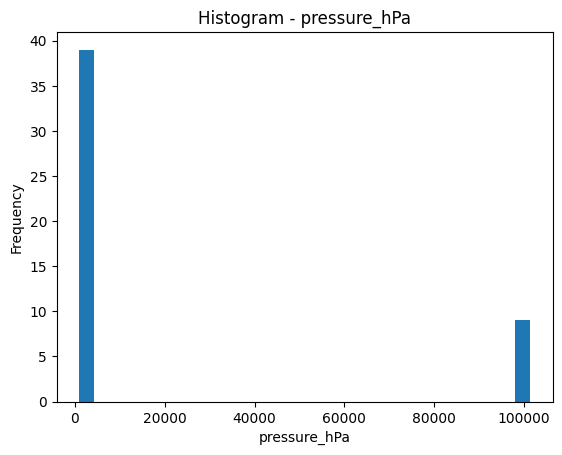

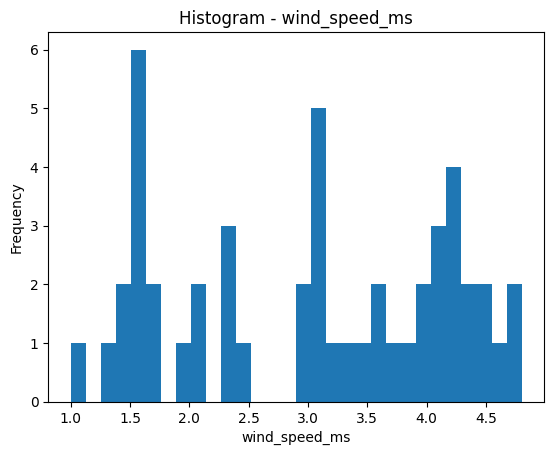

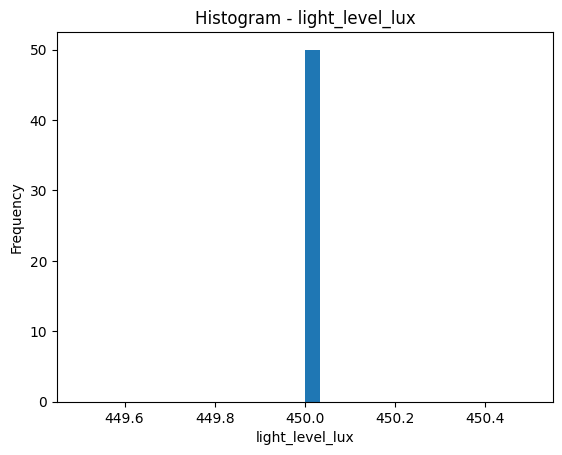

In [ ]:
for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Outlier

In [ ]:
print("OUTLIER (Domain Based)")

outliers = {}

# Temperature realistis
outliers['temperature_C'] = df[
    (df['temperature_C'] < -50) | (df['temperature_C'] > 60)
]

# Humidity realistis
outliers['humidity_pct'] = df[
    (df['humidity_pct'] < 0) | (df['humidity_pct'] > 100)
]

# Pressure realistis
outliers['pressure_hPa'] = df[
    (df['pressure_hPa'] < 800) | (df['pressure_hPa'] > 1100)
]

# Wind speed realistis
outliers['wind_speed_ms'] = df[
    (df['wind_speed_ms'] < 0) | (df['wind_speed_ms'] > 60)
]

# Light lux realistis
outliers['light_level_lux'] = df[
    (df['light_level_lux'] < 0)
]

for col, data in outliers.items():
    if len(data) > 0:
        print(f"\nOutlier ditemukan di {col}:")
        display(data[['timestamp', col]])

OUTLIER (Domain Based)

Outlier ditemukan di humidity_pct:


,timestamp,humidity_pct
7,2026-01-01 15:00:00,120.0
22,2026-01-02 06:00:00,-15.0
41,2026-01-03 01:00:00,150.0



Outlier ditemukan di pressure_hPa:


,timestamp,pressure_hPa
20,2026-01-02 04:00:00,101364.55
21,2026-01-02 05:00:00,101279.53
22,2026-01-02 06:00:00,101395.14
23,2026-01-02 07:00:00,101254.91
24,2026-01-02 08:00:00,101354.34
26,2026-01-02 10:00:00,101275.47
27,2026-01-02 11:00:00,101296.69
28,2026-01-02 12:00:00,101329.98
29,2026-01-02 13:00:00,101299.83


### Inlier

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values('timestamp').reset_index(drop=True)
print("Start time :", df['timestamp'].min())
print("End time   :", df['timestamp'].max())
print("Total rows :", len(df))

# buat index waktu lengkap per jam
full_time = pd.date_range(
    start=df['timestamp'].min(),
    end=df['timestamp'].max(),
    freq='H'
)

print("Expected total hours:", len(full_time))

Start time : 2026-01-01 08:00:00
End time   : 2026-01-03 09:00:00
Total rows : 50
Expected total hours: 50


/var/folders/91/f899zz6x4731k595sdcfccwc0000gn/T/ipykernel_4233/473170977.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_time = pd.date_range(


In [ ]:
df_full = df.set_index('timestamp').reindex(full_time)

df_full.head(10)

,temperature_C,humidity_pct,pressure_hPa,wind_speed_ms,light_level_lux
2026-01-01 08:00:00,25.15,65.32,1012.54,3.05,450.0
2026-01-01 09:00:00,25.48,64.44,1013.04,3.82,450.0
2026-01-01 10:00:00,26.19,63.65,1013.08,4.16,450.0
2026-01-01 11:00:00,26.87,64.15,1012.85,4.55,450.0
2026-01-01 12:00:00,26.66,63.53,1013.17,4.36,450.0
2026-01-01 13:00:00,NaN,62.23,1013.45,3.61,450.0
2026-01-01 14:00:00,27.47,59.16,1014.19,3.37,450.0
2026-01-01 15:00:00,27.16,120.00,1013.34,2.34,450.0
2026-01-01 16:00:00,26.59,57.83,1013.38,1.46,450.0
2026-01-01 17:00:00,26.58,57.44,1013.21,1.63,450.0


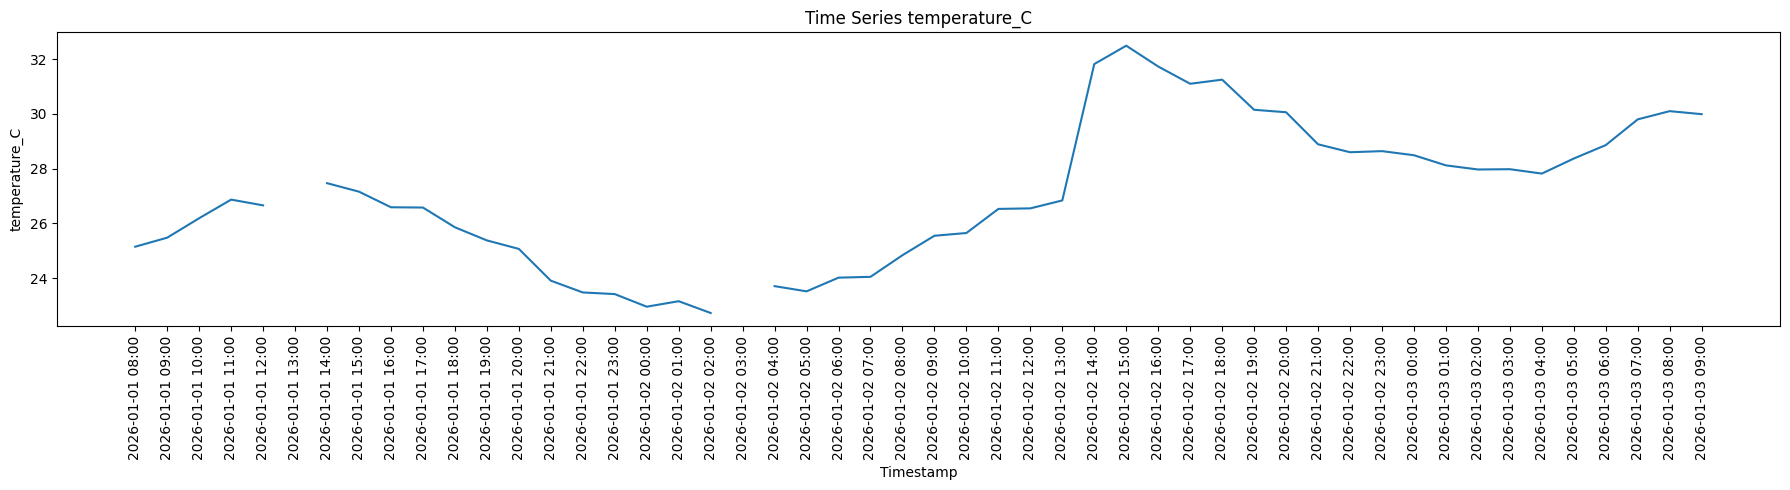

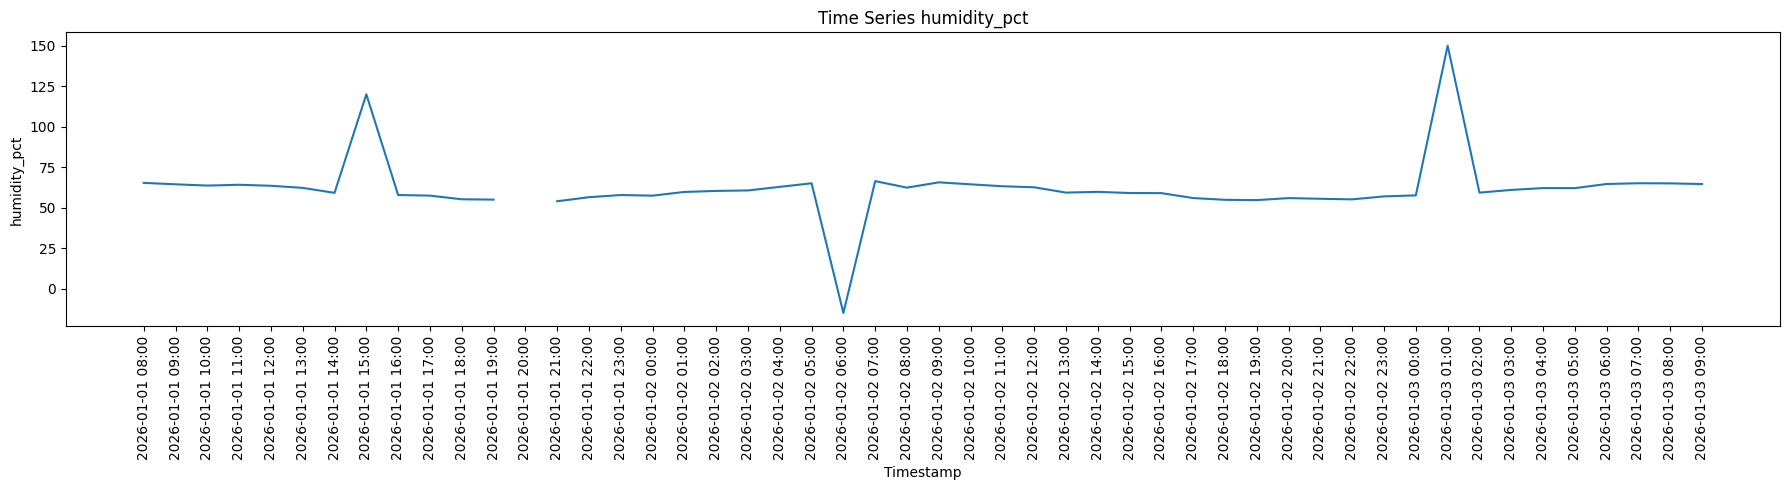

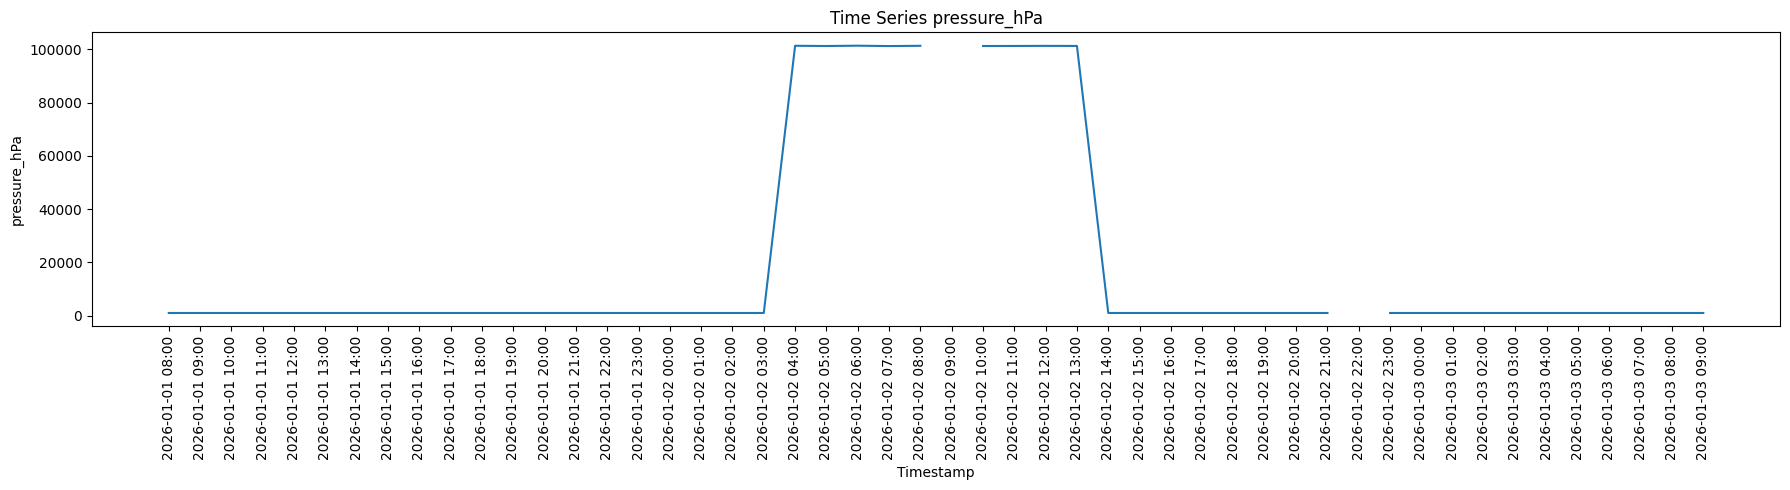

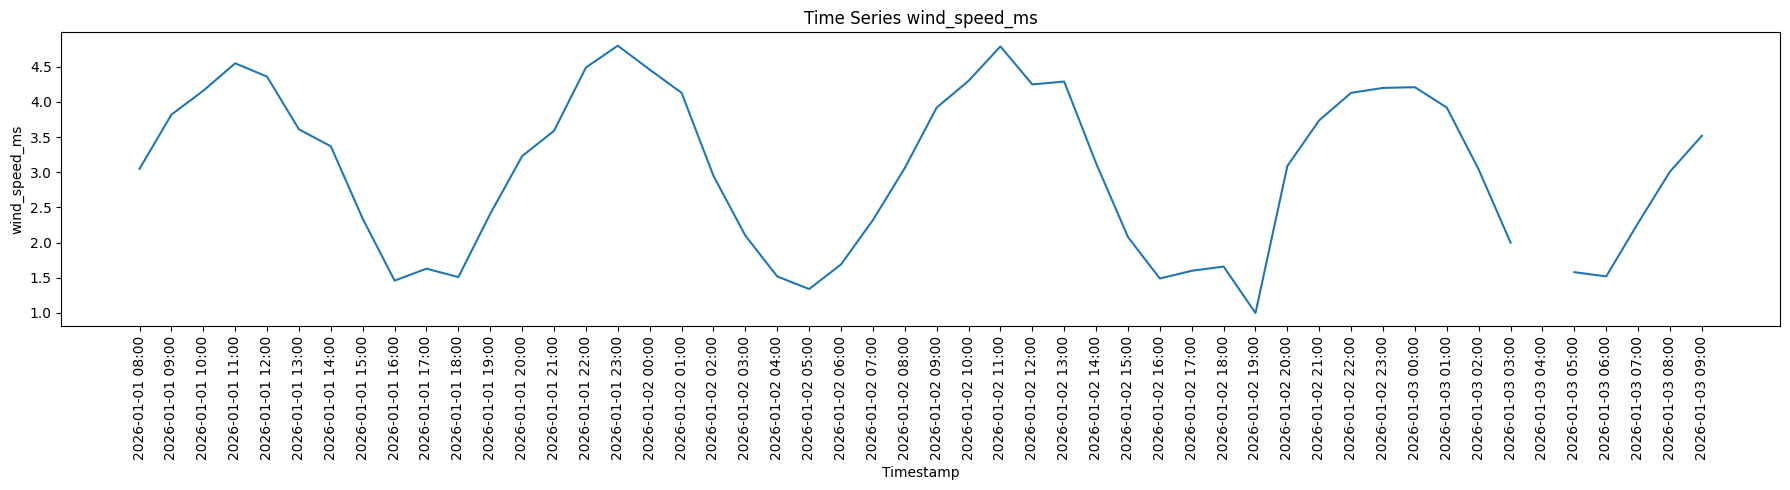

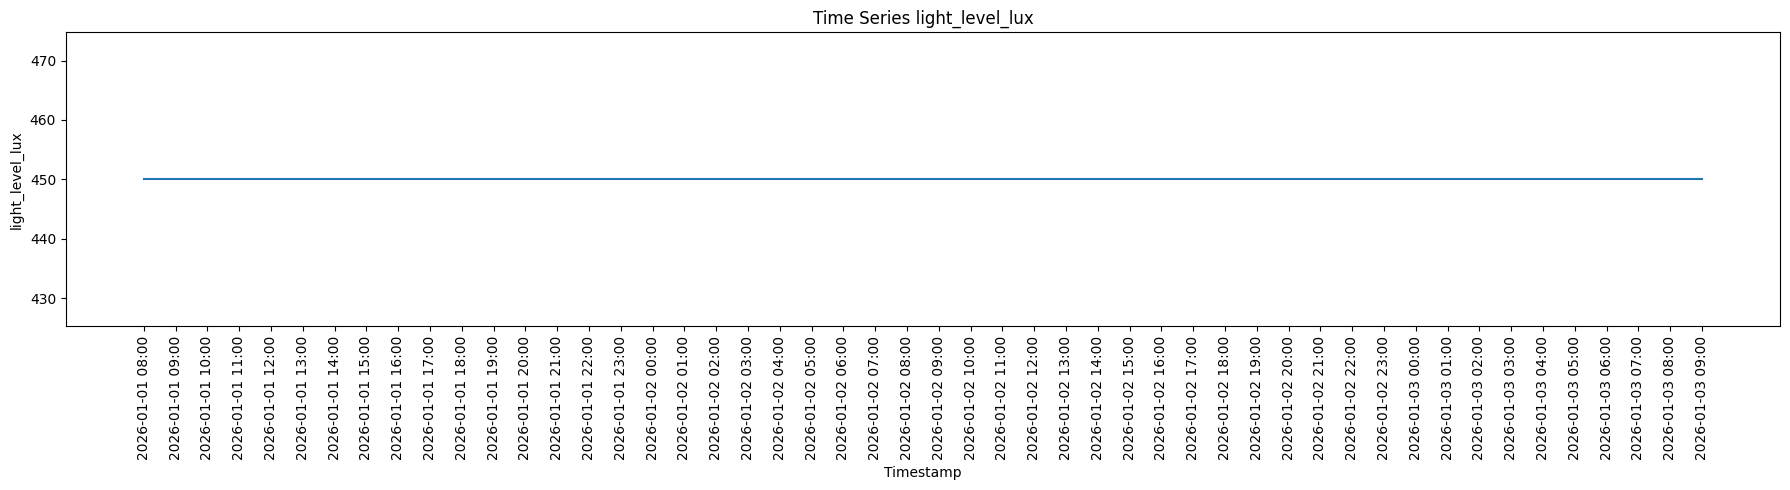

In [ ]:
columns = ['temperature_C','humidity_pct','pressure_hPa','wind_speed_ms','light_level_lux']

for col in columns:
    plt.figure(figsize=(18,5))
    plt.plot(df_full.index, df_full[col])

    plt.title(f"Time Series {col}")
    plt.xlabel("Timestamp")
    plt.ylabel(col)

    plt.xticks(
        ticks=df_full.index,
        labels=df_full.index.strftime('%Y-%m-%d %H:%M'),
        rotation=90
    )

    plt.tight_layout()
    plt.show()

In [ ]:
print("INLIER (Local Anomaly Detection)")

for col in df.select_dtypes(include=np.number).columns:

    # hitung perubahan antar waktu
    diff = df[col].diff().abs()

    threshold = diff.mean() + 3*diff.std()

    anomaly = df[diff > threshold]

    if len(anomaly) > 0:
        print(f"\nInlier anomaly di {col}:")
        display(anomaly[['timestamp', col]])

INLIER (Local Anomaly Detection)

Inlier anomaly di temperature_C:


,timestamp,temperature_C
30,2026-01-02 14:00:00,31.82



Inlier anomaly di humidity_pct:


,timestamp,humidity_pct
41,2026-01-03 01:00:00,150.0
42,2026-01-03 02:00:00,59.3



Inlier anomaly di pressure_hPa:


,timestamp,pressure_hPa
20,2026-01-02 04:00:00,101364.55
30,2026-01-02 14:00:00,1012.47



Inlier anomaly di wind_speed_ms:


,timestamp,wind_speed_ms
36,2026-01-02 20:00:00,3.09
